In [1]:
import os
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score,
                             recall_score, balanced_accuracy_score, f1_score, precision_recall_fscore_support)
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import Adam 
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else 
                     ("mps" if torch.backends.mps.is_available() else "cpu"))

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *
from Utils.lookahead import Lookahead

In [3]:
print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x3c45f7210>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x3c78036d0>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x3c7802950>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x3c7811390>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
toxic_idx = train_class_to_idx['toxic']

In [13]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss)
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [14]:
toxic_weight = 8.0
class_weights = torch.tensor([1.0, 1.0, toxic_weight], dtype=torch.float32, device=device)
criterion = FocalLoss(weight=class_weights, gamma=2.0)

## Training and Validation

### Load RESNET50 Model

In [15]:
clear_memory()

In [16]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

In [17]:
base_opt = torch.optim.RAdam([
    {"params": model.conv1.parameters(), "lr": 1e-5},
    {"params": model.bn1.parameters(), "lr": 1e-5},
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 2e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
], weight_decay=0.01)

optimizer = Lookahead(base_opt, k=5, alpha=0.5)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    base_opt, 
    max_lr=[1e-5, 1e-5, 1e-5, 2e-5, 5e-5, 1e-4, 1e-3], 
    steps_per_epoch=len(train_loader), 
    epochs=30
)

In [18]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [19]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False, scheduler=None):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(img)
            loss = criterion(outputs, labels)
            
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
                if scheduler: scheduler.step()

        preds = outputs.argmax(1)
        running_loss += loss.item() * img.size(0)
        running_correct += (preds == labels).sum().item()
        total += img.size(0)

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            print(f"  {'Train' if is_train else 'Val'} [{i+1}/{num_batches}] Loss: {loss.item():.4f}", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    print() 
    avg_loss = running_loss / total
    avg_acc = running_correct / total

    if return_preds:
        y_true = torch.cat(all_labels).numpy()
        y_pred = torch.cat(all_preds).numpy()
        
        # Metrics Calculation
        bal_acc = balanced_accuracy_score(y_true, y_pred)
        f1_m = f1_score(y_true, y_pred, average='macro')
        f1_w = f1_score(y_true, y_pred, average='weighted')
        
        # F2 since safety first
        prec, rec, f2_score, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=2.0, zero_division=0
        )
        _, _, f1_tox, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[toxic_idx], beta=1.0, zero_division=0
        )
        
        metrics = (avg_loss, avg_acc, bal_acc, f1_m, f1_w, prec[0], rec[0], f1_tox[0], f2_score[0])
        return metrics, y_true, y_pred
    
    return (avg_loss, avg_acc, None, None, None, None, None, None, None), None, None

In [20]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=7, scheduler=None):
    best_composite = -float("inf")
    bad_epochs = 0

    for epoch in range(num_epochs):
        # training
        t_metrics, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True, scheduler=scheduler
        )
        t_loss, t_acc = t_metrics[0], t_metrics[1]
        
        # validation
        v_metrics, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )
        v_loss, v_acc, v_bal, v_f1_m, v_f1_w, v_tox_p, v_tox_r, v_tox_f1, v_prio = v_metrics

        # composite metric
        composite = 0.6 * v_tox_r + 0.4 * v_acc   # recall weighted higher

        current_lr = optimizer.param_groups[-1]['lr']

        print(f"\n{'='*20} EPOCH {epoch+1} {'='*20}")
        print(f"TRAIN: Loss {t_loss:.4f} | Acc {t_acc:.4f}")
        print(f"VAL:   Loss {v_loss:.4f} | Acc {v_acc:.4f} | Balanced: {v_bal:.4f}")
        print(f"TOXIC: Recall: {v_tox_r:.4f} | F2 (Safety): {v_prio:.4f} | Composite: {composite:.4f}")
        print(f"TOXIC F1: {v_tox_f1:.4f} | Macro F1: {v_f1_m:.4f} | Weighted F1: {v_f1_w:.4f}")
        print(f"LR:    {current_lr:.8f}")

        if composite > best_composite:
            best_composite = composite
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(">>> New Best Model Saved (by composite metric)!")
        else:
            bad_epochs += 1
            print(f"No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print(f"!!! Early stopping triggered.")
                break
        
        clear_memory()

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [21]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5, scheduler=None):
    best_priority = -float("inf")
    bad_epochs = 0

    for epoch in range(num_epochs):
        # training dataset
        t_metrics, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True, scheduler=scheduler
        )
        t_loss, t_acc = t_metrics[0], t_metrics[1]
        
        # validation dataset
        v_metrics, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )
        v_loss, v_acc, v_bal, v_f1_m, v_f1_w, v_tox_p, v_tox_r, v_tox_f1, v_prio = v_metrics

        current_lr = optimizer.param_groups[-1]['lr']

        print(f"\n{'='*20} EPOCH {epoch+1} {'='*20}")
        print(f"TRAIN: Loss {t_loss:.4f} | Acc {t_acc:.4f}")
        print(f"VAL:   Loss {v_loss:.4f} | Acc {v_acc:.4f} | Balanced: {v_bal:.4f}")
        print(f"TOXIC: Recall: {v_tox_r:.4f} | F2 (Safety): {v_prio:.4f}")
        print(f"LR:    {current_lr:.8f}")

        # Early Stopping Logic
        if v_prio > best_priority:
            best_priority = v_prio
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(">>> New Best Model Saved!")
        else:
            bad_epochs += 1
            print(f"No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print(f"!!! Early stopping triggered.")
                break
        
        clear_memory()

    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [22]:
# optimal threshold for toxic class
model.eval()
val_toxic_probs = []
val_labels = []
with torch.no_grad():
    for img, labels in val_loader:
        img = img.to(device)
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        val_toxic_probs.append(probs[:, toxic_idx].cpu())
        val_labels.append(labels.cpu())

val_toxic_probs = torch.cat(val_toxic_probs).numpy()
val_labels = torch.cat(val_labels).numpy()

# 1 if toxic, 0 otherwise
true_binary = (val_labels == toxic_idx).astype(int)

print(f"Toxic samples in validation: {true_binary.sum()} / {len(true_binary)}")

Toxic samples in validation: 1606 / 4818


In [23]:
# look for threshold that gives highest recall
best_recall = 0
best_thresh = 0.5
thresholds = np.linspace(0.1, 0.9, 50)
recalls = []
for thresh in thresholds:
    preds_binary = (val_toxic_probs > thresh).astype(int)
    recall = recall_score(true_binary, preds_binary)
    recalls.append(recall)
    if recall > best_recall:
        best_recall = recall
        best_thresh = thresh
print(f"Optimal threshold for toxic class: {best_thresh:.3f} (recall = {best_recall:.4f})")

Optimal threshold for toxic class: 0.100 (recall = 1.0000)


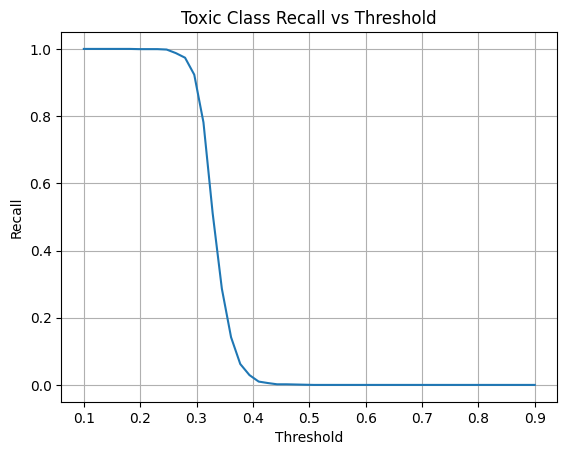

In [24]:
plt.plot(thresholds, recalls)
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Toxic Class Recall vs Threshold")
plt.grid(True)
plt.savefig(save_dir / "toxic_recall_vs_threshold.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
model = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=7, scheduler=scheduler)

  Train [151/151] Loss: 2.9724
  Val [19/19] Loss: 2.7182

==================== EPOCH 1 ====================
TRAIN: Loss 3.2993 | Acc 0.3160
VAL:   Loss 3.0460 | Acc 0.3223 | Balanced: 0.3223
TOXIC: Recall: 0.7441 | F2 (Safety): 0.5922
LR:    0.00006899
>>> New Best Model Saved!
  Train [151/151] Loss: 1.7833
  Val [19/19] Loss: 1.6823

==================== EPOCH 2 ====================
TRAIN: Loss 2.4126 | Acc 0.3327
VAL:   Loss 1.6650 | Acc 0.3333 | Balanced: 0.3333
TOXIC: Recall: 1.0000 | F2 (Safety): 0.7143
LR:    0.00015246
>>> New Best Model Saved!
  Train [151/151] Loss: 1.2381
  Val [19/19] Loss: 1.2093

==================== EPOCH 3 ====================
TRAIN: Loss 1.4058 | Acc 0.3333
VAL:   Loss 1.1658 | Acc 0.3333 | Balanced: 0.3333
TOXIC: Recall: 1.0000 | F2 (Safety): 0.7143
LR:    0.00028032
No improvement. Patience: 1/7
  Train [151/151] Loss: 1.1345
  Val [19/19] Loss: 0.9518

==================== EPOCH 4 ====================
TRAIN: Loss 1.1189 | Acc 0.3348
VAL:   Loss 0.9

In [56]:
models_dir = PROJECT_ROOT / "best_models"
models_dir.mkdir(parents=True, exist_ok=True)
model_save_path = models_dir / "Mushroom_ResNet50_Robust_Final.pth"
torch.save(model.state_dict(), model_save_path)

In [52]:
from sklearn.metrics import precision_score
best_prec_at_99 = 0
best_thresh_99 = 0.5
precisions_at_99 = []

for thresh in thresholds: 
    preds_binary = (val_toxic_probs > thresh).astype(int)
    recall = recall_score(true_binary, preds_binary)
    if recall >= 0.99:
        precision = precision_score(true_binary, preds_binary)
        precisions_at_99.append((thresh, precision, recall))
        if precision > best_prec_at_99:
            best_prec_at_99 = precision
            best_thresh_99 = thresh

if best_thresh_99 != 0.5:
    print(f"Threshold with recall >=0.99 and highest precision: {best_thresh_99:.3f}")
    print(f"- Recall = {recall_score(true_binary, (val_toxic_probs > best_thresh_99).astype(int)):.4f}")
    print(f"- Precision = {best_prec_at_99:.4f}")
else:
    print("No threshold achieves recall >= 0.99.")

best_thresh = best_thresh_99   

Threshold with recall >=0.99 and highest precision: 0.247
- Recall = 0.9981
- Precision = 0.3338


In [41]:
print("FINAL EVALUATION ON TEST SET (with threshold 0.1)")
best_thresh = 0.1   # from your validation search

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for img, labels in test_loader:
        img = img.to(device)
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        toxic_probs = probs[:, toxic_idx]
        
        batch_size = img.size(0)
        preds = torch.full((batch_size,), toxic_idx, dtype=torch.long, device=device)
        non_toxic_mask = toxic_probs <= best_thresh
        if non_toxic_mask.any():
            other_classes = [i for i in range(len(CLASSES)) if i != toxic_idx]
            other_logits = outputs[:, other_classes]
            other_preds = other_logits.argmax(dim=1)
            preds[non_toxic_mask] = torch.tensor(other_classes, device=device)[other_preds[non_toxic_mask]]
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_probs.append(toxic_probs.cpu())

y_true = torch.cat(all_labels).numpy()
y_pred = torch.cat(all_preds).numpy()

FINAL EVALUATION ON TEST SET (with threshold 0.1)


In [43]:
bal_acc = balanced_accuracy_score(y_true, y_pred)
f1_m = f1_score(y_true, y_pred, average='macro')
f1_w = f1_score(y_true, y_pred, average='weighted')
prec, rec, f1_tox, _ = precision_recall_fscore_support(y_true, y_pred, labels=[toxic_idx], beta=1.0)
_, _, f2_tox, _ = precision_recall_fscore_support(y_true, y_pred, labels=[toxic_idx], beta=2.0)

In [44]:
print(f"Accuracy:  {np.mean(y_true == y_pred):.4f} (Balanced: {bal_acc:.4f})")
print(f"F2 Score (Priority): {f2_tox[0]:.4f}")
print(f"Macro F1: {f1_m:.4f} | Weighted F1: {f1_w:.4f}")
print(f"Toxic F1: {f1_tox[0]:.4f}")
print("-" * 50)
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Accuracy:  0.7957 (Balanced: 0.7957)
F2 Score (Priority): 0.9026
Macro F1: 0.7943 | Weighted F1: 0.7943
Toxic F1: 0.8082
--------------------------------------------------

Detailed Classification Report:
                      precision    recall  f1-score   support

conditionally_edible     0.9142    0.6972    0.7911      1605
              edible     0.8724    0.7111    0.7835      1606
               toxic     0.6883    0.9788    0.8082      1606

            accuracy                         0.7957      4817
           macro avg     0.8250    0.7957    0.7943      4817
        weighted avg     0.8249    0.7957    0.7943      4817



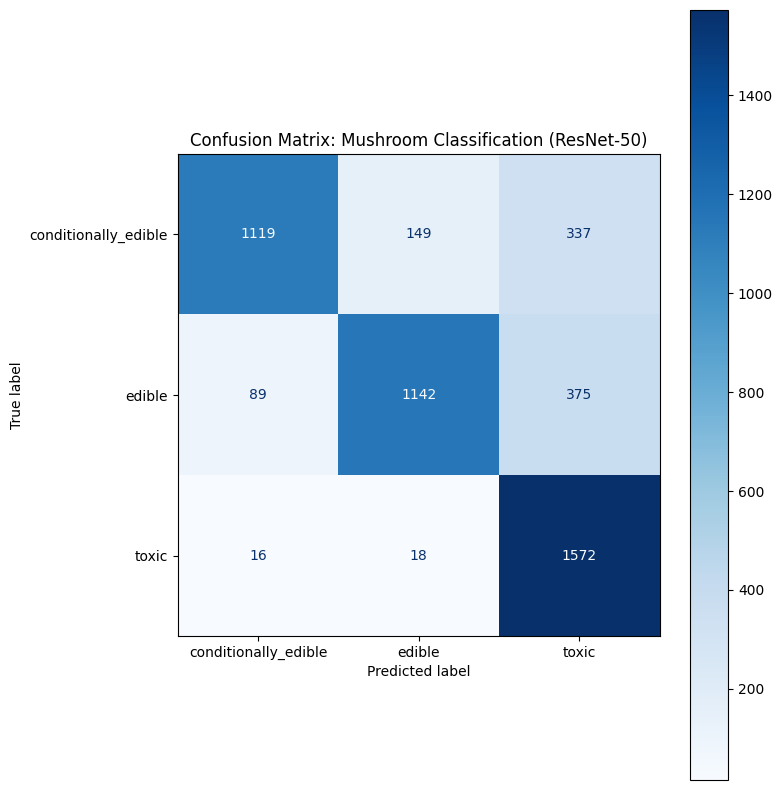

In [45]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title("Confusion Matrix: Mushroom Classification (ResNet-50)")
plt.tight_layout()
plt.savefig("resnet50_final_confusion_matrix.png", dpi=300)
plt.show()

torch.save(model.state_dict(), "Mushroom_ResNet50_Robust_Final.pth")

In [57]:
clear_memory()